<span style="color:blue; font-style:italic; font-size:30px;"># Sets Up</span>

In [2]:
import os
import glob, cv2, numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf

#### 1. From Huggingface (https://huggingface.co/Links to an external site.) select and download a pre-trained CLIP model (you can use your own computer, Colab, Kaggle... to store the model). Describe the model you downloaded - what is its architecture (e.g. CNN/ViT), number of layers, parameters per layer - breakdown the parameters and explain what they are doing (e.g. are they parts of K, Q and V matrices, bias, feature maps, dense layer...). [10 points]

In [3]:
from transformers import CLIPProcessor, CLIPModel
from collections import defaultdict
import torch

In [14]:
# Load the model and processor
model_name = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name)
processor = CLIPProcessor.from_pretrained(model_name)

In [5]:
# Summary of the model architecture
print(model)

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPSdpaAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e

In [6]:
# Count total number of parameters and breakdown
def analyze_parameters(model):
    param_summary = defaultdict(int)
    for name, param in model.named_parameters():
        if param.requires_grad:
            if 'q_proj' in name:
                param_summary['Query'] += param.numel()
            elif 'k_proj' in name:
                param_summary['Key'] += param.numel()
            elif 'v_proj' in name:
                param_summary['Value'] += param.numel()
            elif 'out_proj' in name:
                param_summary['Output projection'] += param.numel()
            elif 'fc1' in name or 'fc2' in name:
                param_summary['Feed Forward Network'] += param.numel()
            elif 'norm' in name:
                param_summary['LayerNorm'] += param.numel()
            elif 'embeddings' in name:
                param_summary['Embedding'] += param.numel()
            elif 'bias' in name:
                param_summary['Bias'] += param.numel()
            else:
                param_summary['Other'] += param.numel()

    total = sum(param_summary.values())
    print("Total trainable parameters:", total)
    for k, v in param_summary.items():
        print(f"{k:25}: {v:,}")

analyze_parameters(model)


Total trainable parameters: 151277313
Other                    : 655,361
Embedding                : 27,734,784
Key                      : 10,238,976
Value                    : 10,238,976
Query                    : 10,238,976
Output projection        : 10,238,976
LayerNorm                : 65,536
Feed Forward Network     : 81,865,728


- ViT architecture means image is split into patches (e.g. 32x32)
- Each patch is embedded and passed through Transformer layers
- Each Transformer layer has multi-head attention with K, Q, V + MLP blocks
- CLIP jointly trains text and image encoders so that their embeddings align in shared space

#### 2. The dataset contains images from the following eight categories: airplane, car, chair, cup, dog, donkey, duck and hat. Each category contains images in five different conditions: realistic, geons, silhouettes, blured and features. Evaluate the model for each condition separately. For each image in the dataset, feed the image into the model together with a text label of a particular category (for each image, evaluate labels of all eight categories). If the model outputs highest correlation for the correct label, consider that as correct classification and otherwise as incorrect classification. Create a confusion matrix and quantify model accuracy for each of the five conditions. [15 points]

In [7]:
from sklearn.metrics import confusion_matrix, accuracy_score
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

# Define categories
categories = ["airplane", "car", "chair", "cup", "dog", "donkey", "duck", "hat"]
prompts = [f"a photo of a {label}" for label in categories]

# Define conditions
conditions = ["realistic", "geons", "silhouettes", "blurred", "features"]

# Dataset path
dataset_root = "image_files/v0" 

results = {}

In [9]:
for condition in conditions:
    print(f"Evaluating condition: {condition}")
    true_labels = []
    pred_labels = []

    condition_path = os.path.join(dataset_root, condition)
    if not os.path.exists(condition_path):
        print(f"Warning: {condition_path} does not exist. Skipping.")
        continue

    image_files_list = [f for f in os.listdir(condition_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
    if not image_files_list:
        print(f"No images found for condition: {condition}. Skipping plot.")
        continue

    for img_file in image_files_list:
        img_path = os.path.join(condition_path, img_file)
        image = Image.open(img_path).convert("RGB")

        # Infer true label from file name
        true_category = None
        for i, cat in enumerate(categories):
            if cat in img_file.lower():
                true_category = i
                break
        if true_category is None:
            print(f"Skipping {img_file} - no valid category found in name")
            continue

        # Process input
        inputs = processor(text=prompts, images=[image] * len(prompts), return_tensors="pt", padding=True).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits_per_image = outputs.logits_per_image
            probs = logits_per_image.softmax(dim=1)

        pred_idx = probs.argmax(dim=1)[0].item()

        true_labels.append(true_category)
        pred_labels.append(pred_idx)

    # Compute confusion matrix and accuracy
    if not true_labels:
        print(f"No valid images for {condition}. Skipping.")
        continue

    cm = confusion_matrix(true_labels, pred_labels)
    acc = accuracy_score(true_labels, pred_labels)

    results[condition] = {
        "confusion_matrix": cm,
        "accuracy": acc
    }

Evaluating condition: realistic
Evaluating condition: geons
Skipping page 8-3.jpg - no valid category found in name
Evaluating condition: silhouettes
Evaluating condition: blurred
Evaluating condition: features
Skipping ChariThreeQuarters_V4.jpg - no valid category found in name


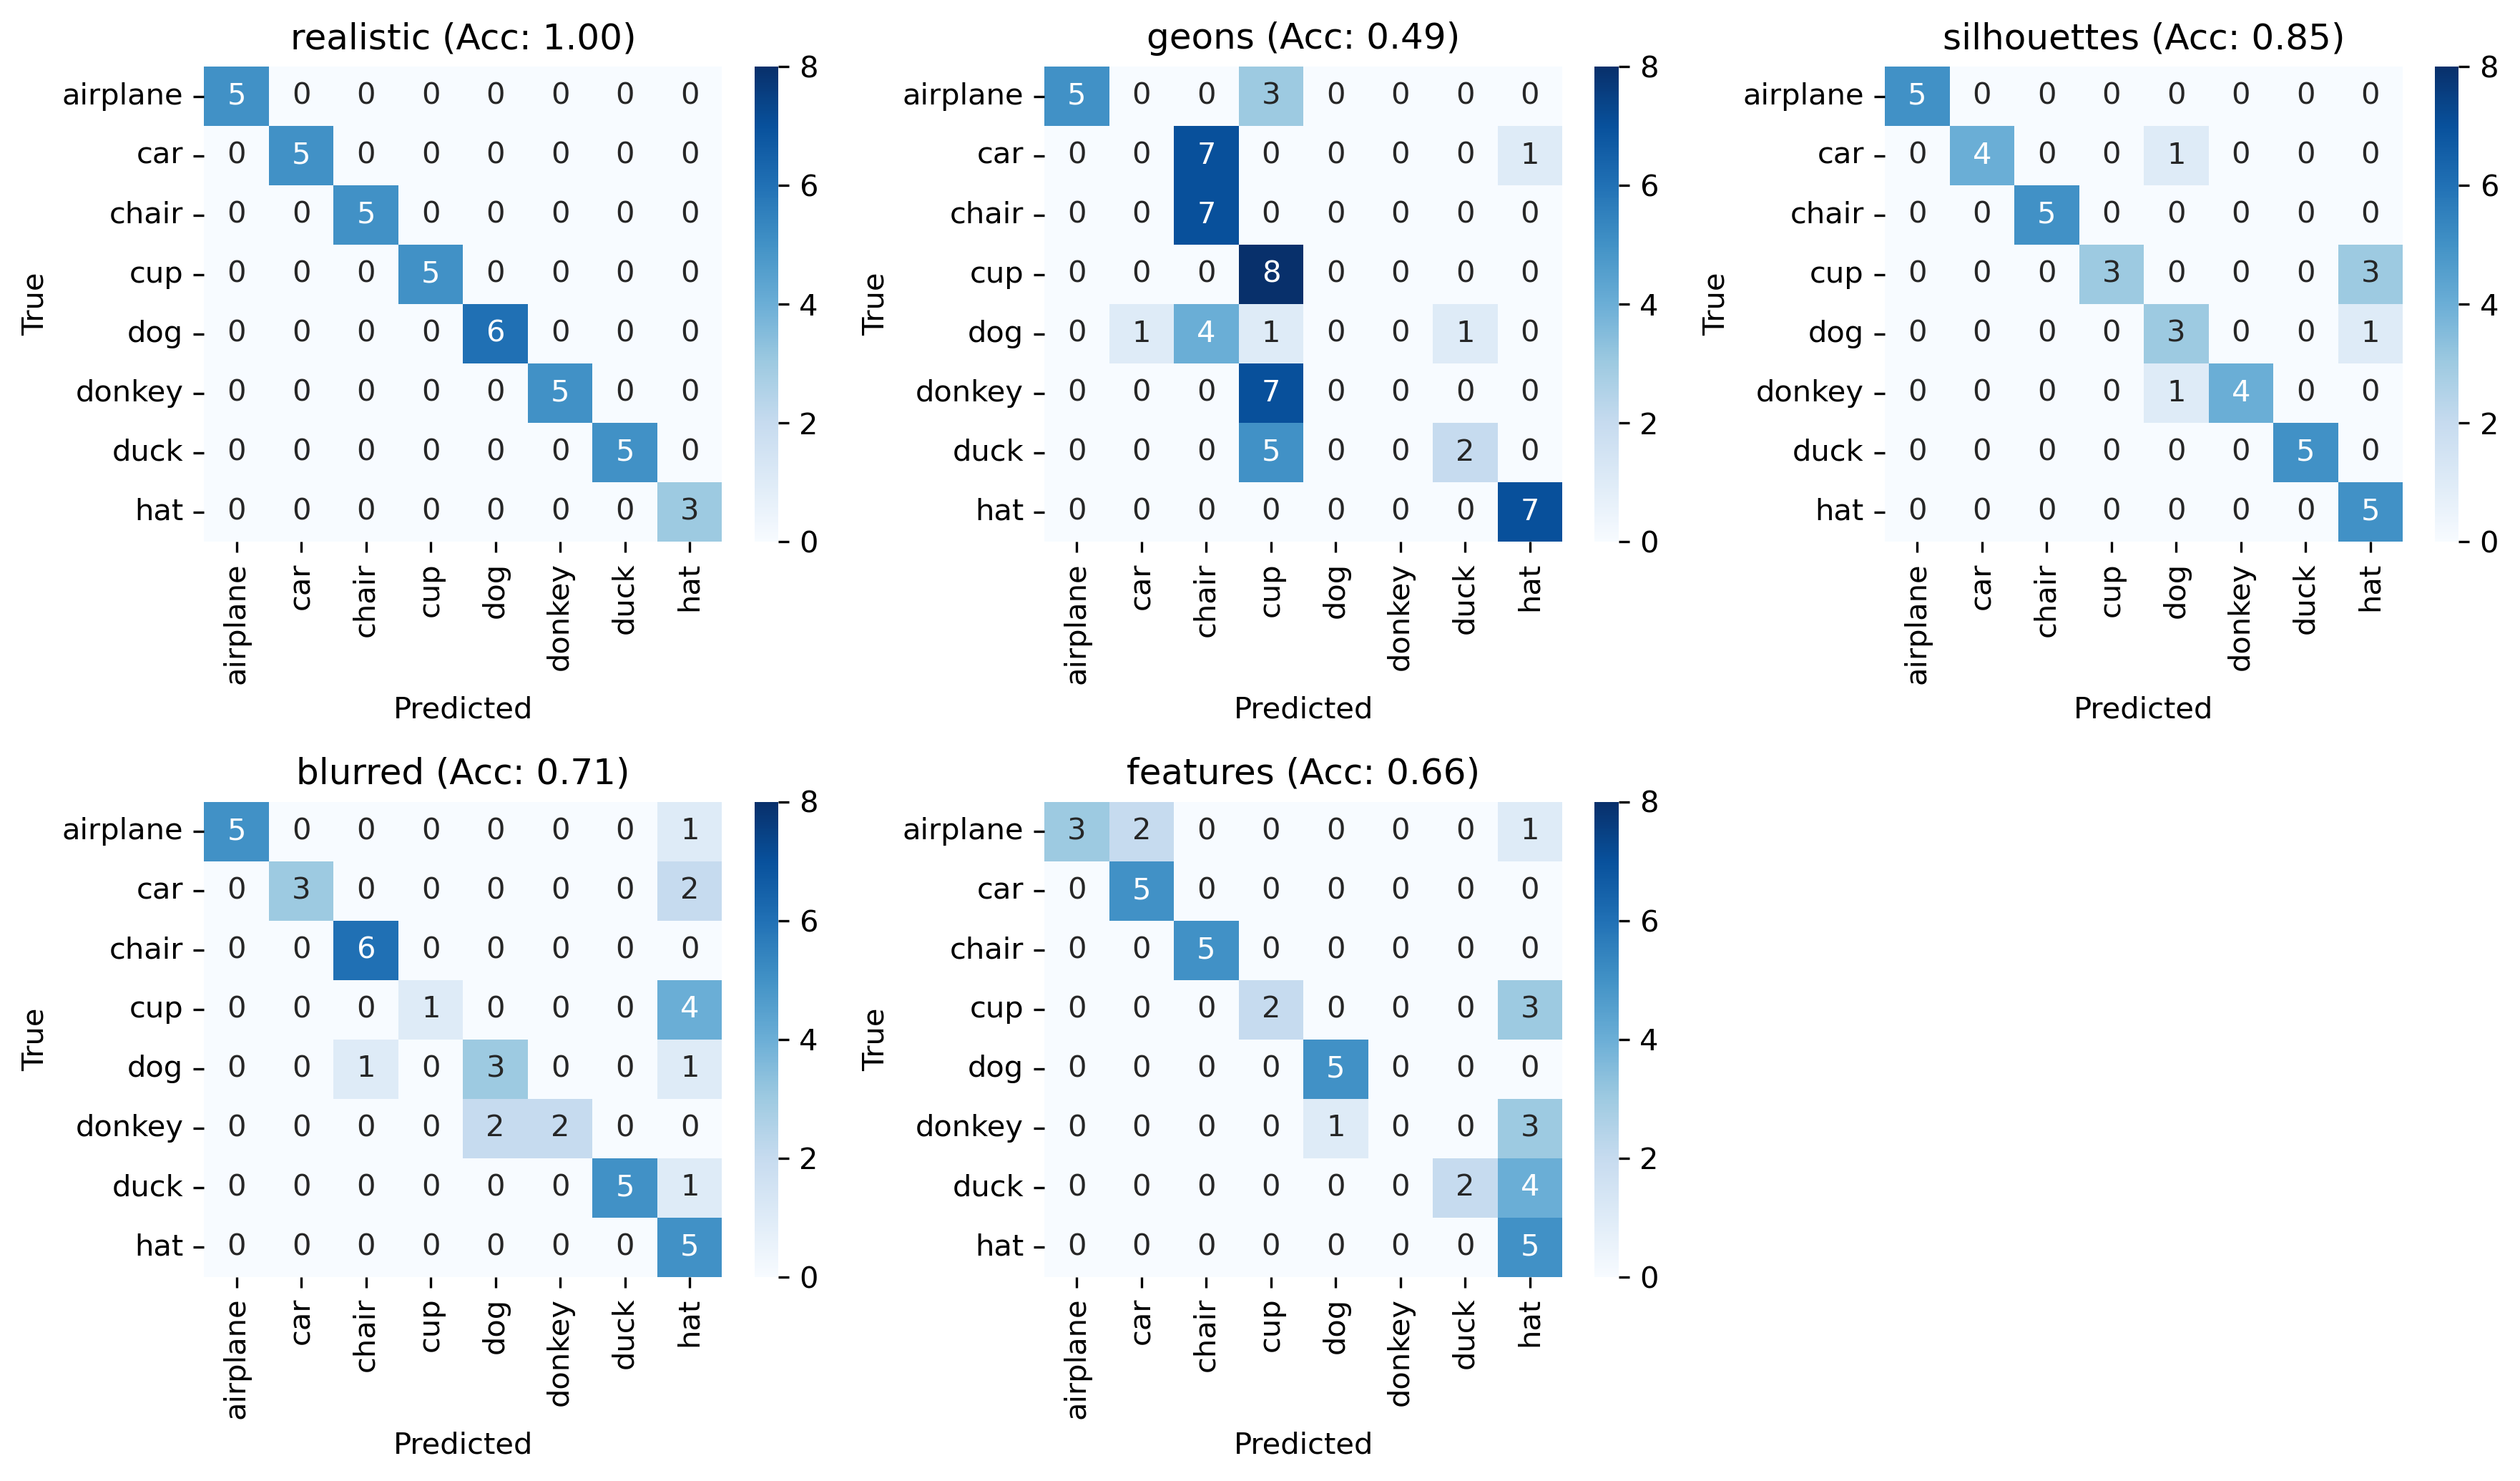

realistic - Accuracy: 1.0000
geons - Accuracy: 0.4915
silhouettes - Accuracy: 0.8500
blurred - Accuracy: 0.7143
features - Accuracy: 0.6585


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7), dpi=300)
axes = axes.flatten()

for idx, (condition, res) in enumerate(results.items()):
    cm = res['confusion_matrix']
    acc = res['accuracy']

    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=categories, yticklabels=categories, ax=ax, vmax=8)
    ax.set_title(f"{condition} (Acc: {acc:.2f})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

# Remove unused subplot
if len(results) < len(axes):
    for j in range(len(results), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Print final summary
for cond, res in results.items():
    print(f"{cond} - Accuracy: {res['accuracy']:.4f}")


#### In which conditions is your models better/worse/similar to babies (Fig. 3A in this paper: https://osf.io/preprints/psyarxiv/83gaeLinks to an external site.)?  [5 points]

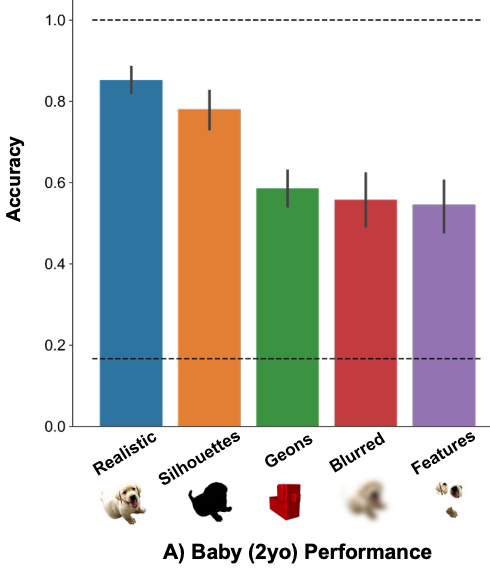

Model performs better than babies:
- Realistic: CLIP = 100% vs Baby ≈ 85%
- Silhouettes: CLIP = 85% vs Baby ≈ 78%
- Blurred: CLIP ≈ 71% vs Baby ≈ 56%

Model performs similar to babies:
- Features: CLIP ≈ 66% vs Baby ≈ 55%


Model performs slightly worse or uncertain:
- Geons: CLIP ≈ 49% vs Baby ≈ 59%

#### 3. From the output of the final layer of the vision encoder (before the projection layer into the shared embedding space) take embeddings for each image in the dataset. Apply t-SNE to those embeddings and plot them in a 2D space - plot little images of objects in the embedding space (something like Fig. 4 in this paper: httpsLinks to an external site. but no need for color coding of bounding boxes). [20 points]

In [11]:
from sklearn.manifold import TSNE
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

In [12]:
# Collect embeddings and images
embeddings = []
images = []

vision_model = model.vision_model  # access encoder before projection layer

for condition in conditions:
    condition_path = os.path.join(dataset_root, condition)
    image_files_list = [f for f in os.listdir(condition_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

    for img_file in image_files_list:
        img_path = os.path.join(condition_path, img_file)
        image = Image.open(img_path).convert("RGB")
        images.append(image)

        inputs = processor(images=image, return_tensors="pt").to(device)
        with torch.no_grad():
            output = vision_model(**inputs)
            last_hidden_state = output.last_hidden_state  # [1, seq_len, hidden_dim]
            img_embedding = last_hidden_state[:, 0, :]     # CLS token
            embeddings.append(img_embedding.squeeze().cpu().numpy())

# Reduce dimensions with t-SNE
X = np.stack(embeddings)
X_embedded = TSNE(n_components=2, random_state=42).fit_transform(X)

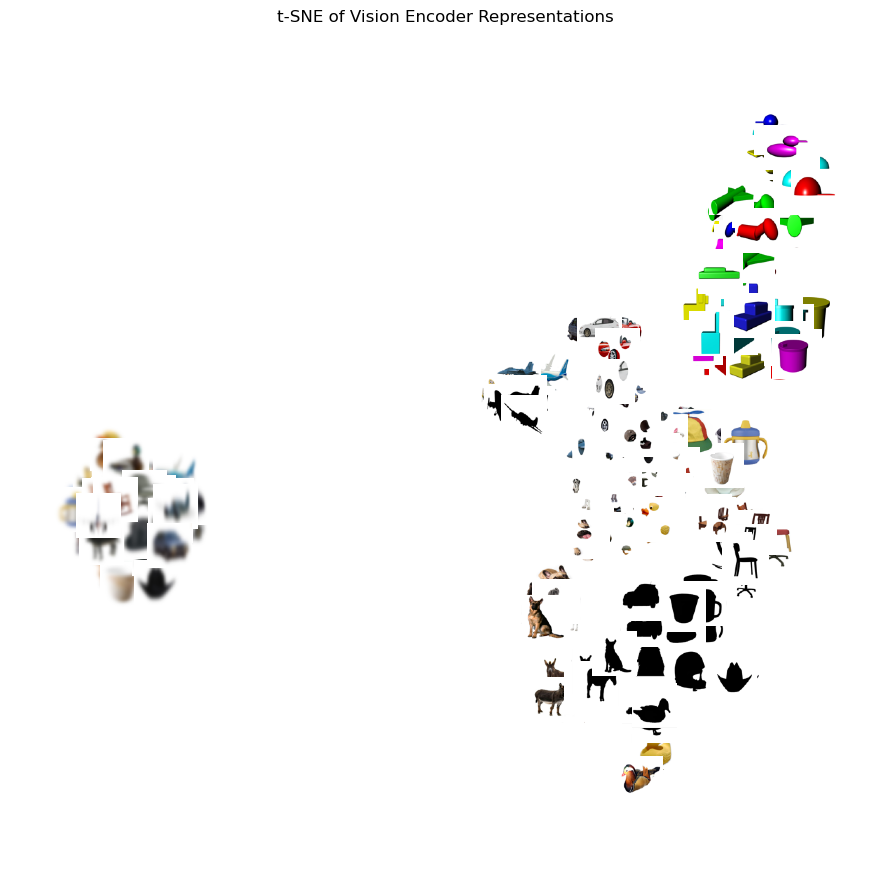

In [13]:
fig, ax = plt.subplots(figsize=(9, 9))
ax.set_title("t-SNE of Vision Encoder Representations")

for i in range(len(X_embedded)):
    try:
        xy = X_embedded[i]
        img = images[i].resize((64, 64)).convert("RGB")  
        img_array = np.array(img)

        im = OffsetImage(img_array, zoom=0.5)  
        ab = AnnotationBbox(im, xy, frameon=False)
        ax.add_artist(ab)

    except Exception as e:
        print(f"Skipping image {i}: {e}")

ax.set_xlim(X_embedded[:, 0].min() - 5, X_embedded[:, 0].max() + 5)
ax.set_ylim(X_embedded[:, 1].min() - 5, X_embedded[:, 1].max() + 5)
ax.axis('off')
plt.tight_layout()
plt.show()

